# Food Delivery — ML Pipeline
**A:** EDA + Clustering | **B:** Regression | **C:** Classification

In [7]:
# Run this cell first in Google Colab, then Runtime → Run all
from google.colab import files
import os

if not os.path.exists("/content/Food_Delivery_Dataset.csv"):
    uploaded = files.upload()
    for fname in uploaded:
        if fname != "Food_Delivery_Dataset.csv":
            os.rename(f"/content/{fname}", "/content/Food_Delivery_Dataset.csv")
    print("Upload complete ✓")
else:
    print("Dataset found ✓")


Saving Food Delivery Dataset.csv to Food Delivery Dataset.csv
Upload complete ✓


## Imports

In [8]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns, warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110})

from sklearn.model_selection  import (train_test_split, RandomizedSearchCV,
                                       StratifiedKFold, cross_val_score, cross_val_predict)
from sklearn.compose          import ColumnTransformer
from sklearn.pipeline         import Pipeline
from sklearn.preprocessing    import OneHotEncoder, StandardScaler
from sklearn.impute           import SimpleImputer
from sklearn.cluster          import KMeans
from sklearn.decomposition    import PCA
from sklearn.metrics          import pairwise_distances
from sklearn.linear_model     import LinearRegression, LogisticRegression
from sklearn.tree             import DecisionTreeRegressor
from sklearn.ensemble         import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes      import GaussianNB
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    f1_score, precision_score, recall_score, roc_auc_score,
    average_precision_score, ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)
print("Imports OK ✓")


Imports OK ✓


## Data Loading

In [9]:
import os
path = "/content/Food_Delivery_Dataset.csv" if os.path.exists("/content/Food_Delivery_Dataset.csv") else "Food_Delivery_Dataset.csv"
df = pd.read_csv(path)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(10)


Shape: 1,000 rows × 16 columns


,market_id,store_primary_category,order_protocol,total_items,subtotal,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,created_day,created_holiday,created_at,actual_delivery_time,complaint,complaint_id
0,AREA B,japanese,Protocol 1,4,875,175,350,82.0,79.0,104.0,Saturday,NO,05:04:03,05:38:01,NaN,NaN
1,AREA A,dessert,Protocol 1,5,5345,295,1995,50.0,51.0,68.0,Friday,NO,02:27:48,03:15:36,NaN,NaN
2,AREA A,burger,Protocol 5,4,2150,50,1300,32.0,37.0,56.0,Tuesday,NO,04:15:41,05:29:14,NaN,NaN
3,AREA A,thai,Protocol 5,5,3570,175,1195,61.0,61.0,73.0,Sunday,NO,03:43:41,04:14:56,YES,1.0
4,AREA D,dessert,Protocol 1,3,2485,295,1195,75.0,71.0,107.0,Monday,NO,04:14:36,05:14:07,NaN,NaN
5,AREA A,american,Protocol 1,1,1150,1150,1150,21.0,19.0,25.0,Monday,NO,21:48:11,22:45:50,NaN,NaN
6,AREA B,alcohol,Protocol 5,1,800,800,800,89.0,53.0,73.0,Tuesday,NO,02:29:25,02:57:55,NaN,NaN
7,AREA B,pizza,Protocol 3,1,1735,1735,1735,94.0,96.0,163.0,Tuesday,NO,02:35:51,03:12:44,NaN,NaN
8,AREA C,breakfast,Protocol 1,2,628,179,399,NaN,NaN,NaN,Sunday,NO,23:28:29,00:02:36,NaN,NaN
9,AREA E,dessert,Protocol 1,5,1685,195,380,16.0,12.0,12.0,Wednesday,NO,00:10:27,00:56:44,NaN,NaN


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   market_id                 997 non-null    object 
 1   store_primary_category    974 non-null    object 
 2   order_protocol            997 non-null    object 
 3   total_items               1000 non-null   int64  
 4   subtotal                  1000 non-null   int64  
 5   min_item_price            1000 non-null   int64  
 6   max_item_price            1000 non-null   int64  
 7   total_onshift_partners    920 non-null    float64
 8   total_busy_partners       920 non-null    float64
 9   total_outstanding_orders  920 non-null    float64
 10  created_day               1000 non-null   object 
 11  created_holiday           1000 non-null   object 
 12  created_at                1000 non-null   object 
 13  actual_delivery_time      1000 non-null   object 
 14  complaint

In [11]:
missing = (df.isna().mean()*100).sort_values(ascending=False)
missing = missing[missing > 0]
print("Missing values (%):")
print(missing.round(2).to_string() if not missing.empty else "None")


Missing values (%):
complaint_id                75.6
complaint                   75.6
total_onshift_partners       8.0
total_busy_partners          8.0
total_outstanding_orders     8.0
store_primary_category       2.6
order_protocol               0.3
market_id                    0.3


## Feature Engineering

In [12]:
def time_to_seconds(t):
    h, m, s = map(int, str(t).split(":"))
    return h*3600 + m*60 + s

created_sec = df["created_at"].map(time_to_seconds)
deliv_sec   = df["actual_delivery_time"].map(time_to_seconds)

delta = deliv_sec - created_sec
df["delivery_minutes"] = np.where(delta < 0, delta + 86400, delta) / 60.0
df["complaint_flag"]   = df["complaint"].fillna("NO").eq("YES").astype(int)

df["created_hour"]         = (created_sec // 3600).astype(int)
df["created_time_minutes"] = created_sec / 60.0
df["sin_time"] = np.sin(2*np.pi*df["created_time_minutes"]/1440)
df["cos_time"] = np.cos(2*np.pi*df["created_time_minutes"]/1440)

df["busy_ratio"]         = df["total_busy_partners"] / df["total_onshift_partners"].clip(lower=1)
df["orders_per_partner"] = df["total_outstanding_orders"] / df["total_onshift_partners"].clip(lower=1)
df["free_partners"]      = (df["total_onshift_partners"] - df["total_busy_partners"]).clip(lower=0)
df["avg_item_price"]     = df["subtotal"] / df["total_items"].clip(lower=1)
df["price_range"]        = df["max_item_price"] - df["min_item_price"]

CAT_COLS = ["market_id","store_primary_category","order_protocol","created_day","created_holiday"]
NUM_COLS = ["created_hour","sin_time","cos_time","total_items","subtotal",
            "min_item_price","max_item_price","total_onshift_partners",
            "total_busy_partners","total_outstanding_orders",
            "busy_ratio","orders_per_partner","free_partners","avg_item_price","price_range"]
ALL_FEATURES = CAT_COLS + NUM_COLS

def make_preprocessor():
    try:    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except: ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
    return ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc",  StandardScaler())]), NUM_COLS),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("enc", ohe)]), CAT_COLS)
    ], sparse_threshold=0)

print(f"delivery_minutes: mean={df['delivery_minutes'].mean():.1f}, std={df['delivery_minutes'].std():.1f}")
print(f"complaint_flag  : {df['complaint_flag'].mean():.1%} positive ({df['complaint_flag'].sum()} / {len(df)})")


delivery_minutes: mean=47.3, std=17.1
complaint_flag  : 24.4% positive (244 / 1000)


---
## Task A — EDA

In [13]:
df[NUM_COLS + ['delivery_minutes','complaint_flag']].describe().round(2)

,created_hour,sin_time,cos_time,total_items,subtotal,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders,busy_ratio,orders_per_partner,free_partners,avg_item_price,price_range,delivery_minutes,complaint_flag
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,920.00,920.00,920.00,920.00,920.00,920.00,1000.00,1000.00,1000.00,1000.00
mean,9.01,0.16,0.65,3.15,2674.94,688.05,1141.95,45.66,43.02,60.03,0.94,1.23,4.57,967.30,453.90,47.27,0.24
std,8.78,0.68,0.30,2.39,1859.08,496.88,513.89,33.48,32.33,53.53,0.64,1.57,7.93,476.83,487.95,17.06,0.43
min,0.00,-1.00,-0.65,1.00,275.00,0.00,169.00,0.00,0.00,0.00,0.00,0.00,0.00,108.55,0.00,16.12,0.00
25%,2.00,-0.54,0.49,2.00,1445.00,299.00,799.00,18.00,16.00,19.00,0.82,0.91,0.00,643.65,0.00,35.42,0.00
50%,4.00,0.45,0.73,3.00,2134.00,600.00,1095.00,39.00,36.00,42.00,0.96,1.18,1.00,896.12,325.00,44.27,0.00
75%,19.25,0.72,0.88,4.00,3429.00,976.00,1400.00,65.00,65.00,89.00,1.00,1.46,6.00,1190.88,770.00,55.78,0.00
max,23.00,1.00,1.00,24.00,13019.00,4400.00,4400.00,158.00,146.00,277.00,18.00,47.00,67.00,4400.00,3500.00,133.43,1.00


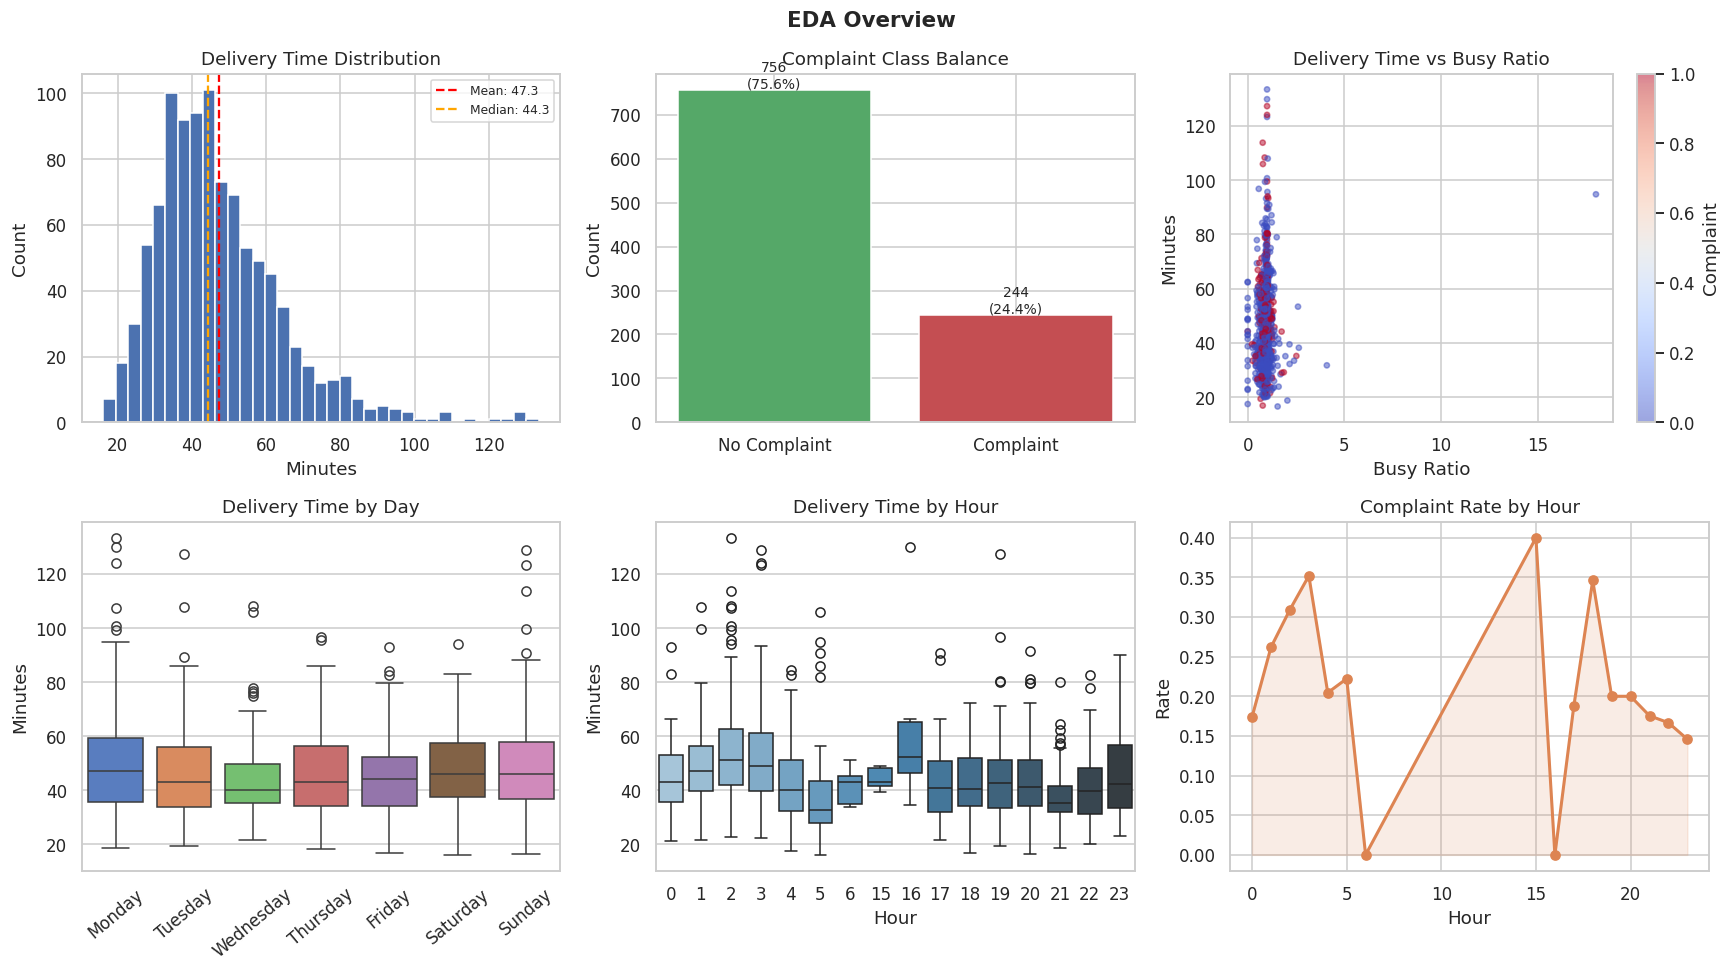

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].hist(df["delivery_minutes"], bins=35, color="#4C72B0", edgecolor="white")
axes[0,0].axvline(df["delivery_minutes"].mean(),   color="red",    lw=1.5, linestyle="--", label=f'Mean: {df["delivery_minutes"].mean():.1f}')
axes[0,0].axvline(df["delivery_minutes"].median(), color="orange", lw=1.5, linestyle="--", label=f'Median: {df["delivery_minutes"].median():.1f}')
axes[0,0].set(title="Delivery Time Distribution", xlabel="Minutes", ylabel="Count"); axes[0,0].legend(fontsize=8)

counts = df["complaint_flag"].value_counts()
bars = axes[0,1].bar(["No Complaint","Complaint"], counts.values, color=["#55A868","#C44E52"], edgecolor="white")
for bar, v in zip(bars, counts.values):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, f"{v}\n({v/len(df):.1%})", ha="center", fontsize=9)
axes[0,1].set(title="Complaint Class Balance", ylabel="Count")

sc = axes[0,2].scatter(df["busy_ratio"], df["delivery_minutes"], c=df["complaint_flag"], cmap="coolwarm", s=12, alpha=0.5)
plt.colorbar(sc, ax=axes[0,2], label="Complaint")
axes[0,2].set(title="Delivery Time vs Busy Ratio", xlabel="Busy Ratio", ylabel="Minutes")

day_order = [d for d in ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"] if d in df["created_day"].unique()]
sns.boxplot(x="created_day", y="delivery_minutes", data=df, order=day_order, ax=axes[1,0], palette="muted")
axes[1,0].set(title="Delivery Time by Day", xlabel="", ylabel="Minutes"); axes[1,0].tick_params(axis="x", rotation=40)

sns.boxplot(x="created_hour", y="delivery_minutes", data=df, ax=axes[1,1], palette="Blues_d")
axes[1,1].set(title="Delivery Time by Hour", xlabel="Hour", ylabel="Minutes")

ch = df.groupby("created_hour")["complaint_flag"].mean()
axes[1,2].plot(ch.index, ch.values, marker="o", color="#DD8452", lw=2)
axes[1,2].fill_between(ch.index, ch.values, alpha=0.15, color="#DD8452")
axes[1,2].set(title="Complaint Rate by Hour", xlabel="Hour", ylabel="Rate")

plt.suptitle("EDA Overview", fontsize=14, fontweight="bold"); plt.tight_layout(); plt.show()


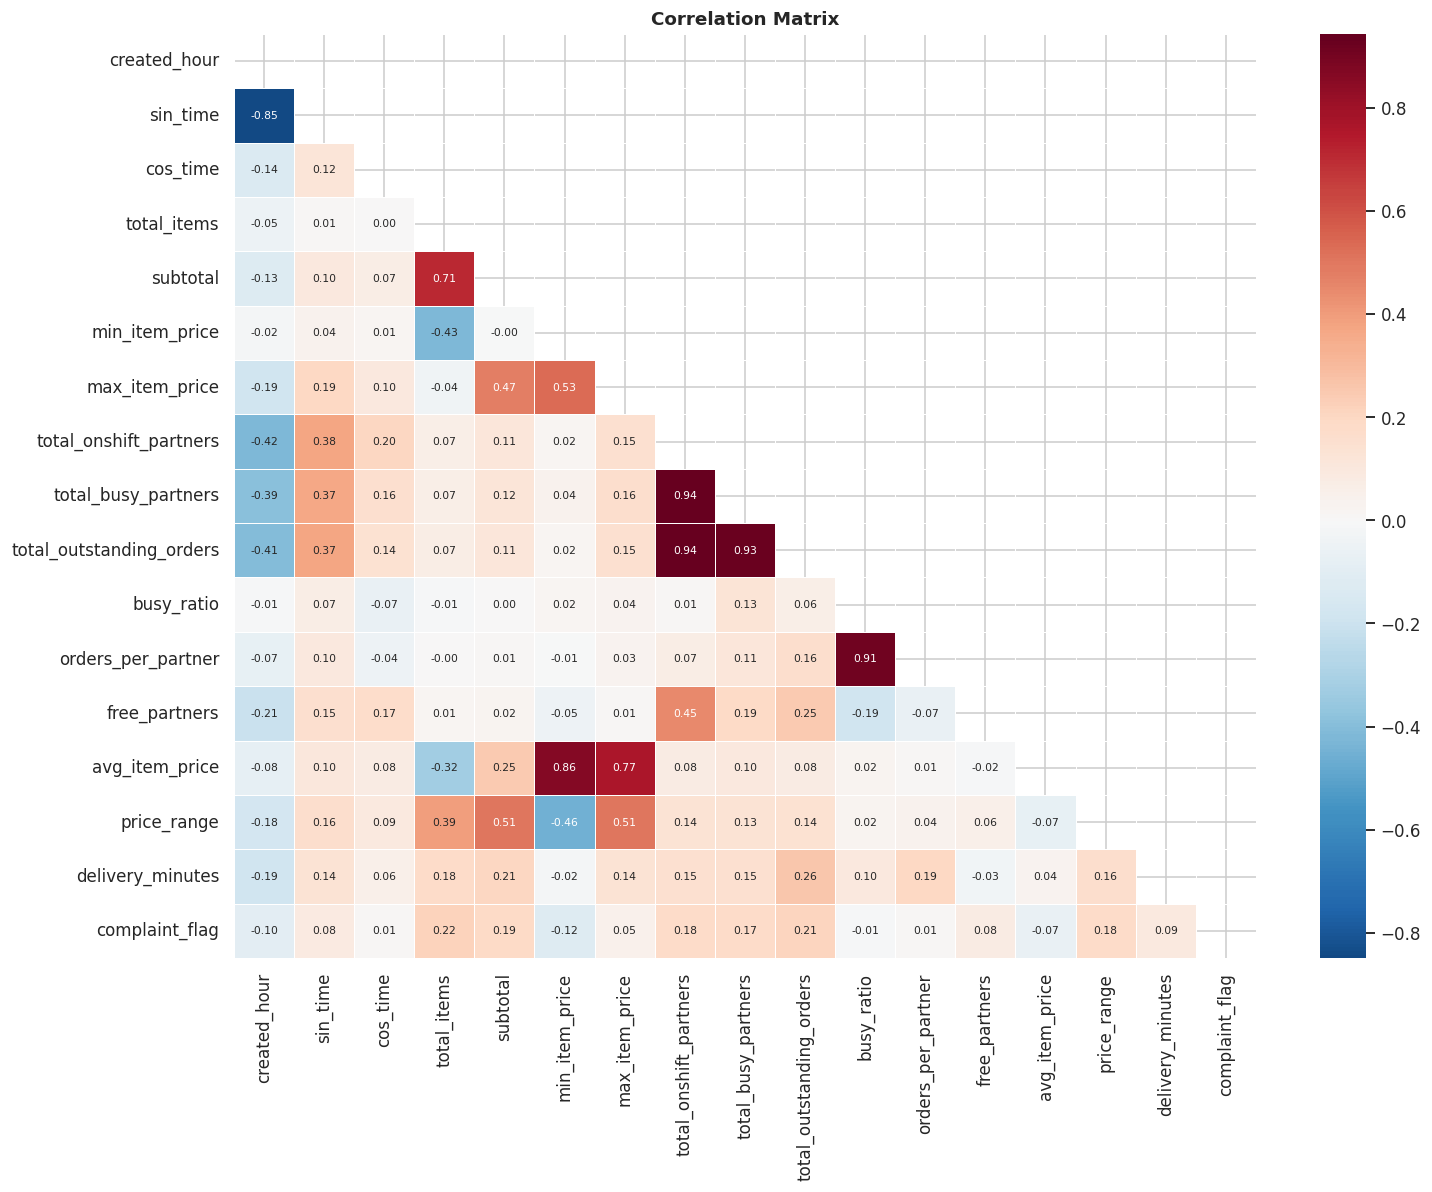

Top 5 vs delivery_minutes:
total_outstanding_orders    0.262
subtotal                    0.207
orders_per_partner          0.194
created_hour                0.185
total_items                 0.183

Top 5 vs complaint_flag:
total_items                 0.220
total_outstanding_orders    0.208
subtotal                    0.190
total_onshift_partners      0.181
price_range                 0.178


In [15]:
corr = df[NUM_COLS + ["delivery_minutes","complaint_flag"]].corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt=".2f", cmap="RdBu_r", center=0, linewidths=0.4, annot_kws={"size":7})
plt.title("Correlation Matrix", fontsize=12, fontweight="bold"); plt.tight_layout(); plt.show()

print("Top 5 vs delivery_minutes:")
print(corr["delivery_minutes"].drop("delivery_minutes").abs().sort_values(ascending=False).head(5).round(3).to_string())
print("\nTop 5 vs complaint_flag:")
print(corr["complaint_flag"].drop("complaint_flag").abs().sort_values(ascending=False).head(5).round(3).to_string())


## Task A — K-Means Clustering

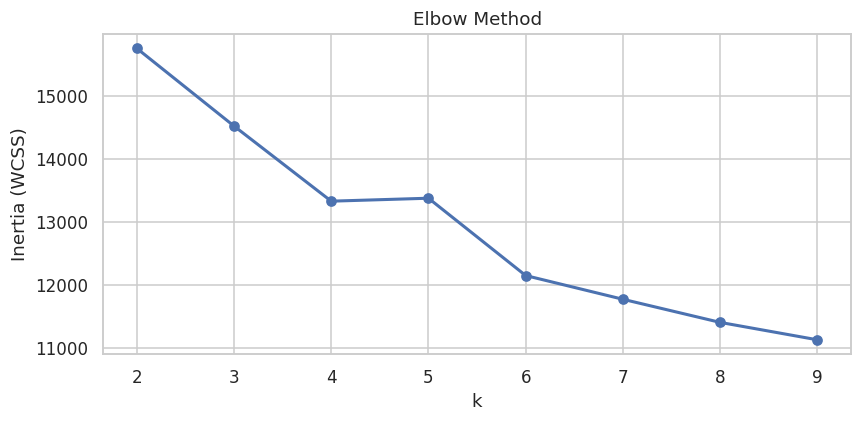

In [16]:
X_clust  = df[ALL_FEATURES].copy()
inertias = []
for k in range(2, 10):
    p = Pipeline([("prep", make_preprocessor()),
                  ("km",   KMeans(n_clusters=k, random_state=42, n_init="auto"))])
    p.fit(X_clust); inertias.append(p.named_steps["km"].inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2,10), inertias, marker="o", color="#4C72B0", lw=2)
plt.xlabel("k"); plt.ylabel("Inertia (WCSS)"); plt.title("Elbow Method"); plt.xticks(range(2,10))
plt.tight_layout(); plt.show()


In [17]:
K = 4
cluster_pipe = Pipeline([("prep", make_preprocessor()),
                          ("km",   KMeans(n_clusters=K, random_state=42, n_init="auto"))])
df["cluster"] = cluster_pipe.fit_predict(X_clust)
print("Cluster counts:"); print(df["cluster"].value_counts().sort_index().to_string())


Cluster counts:
cluster
0     99
1    338
2    218
3    345


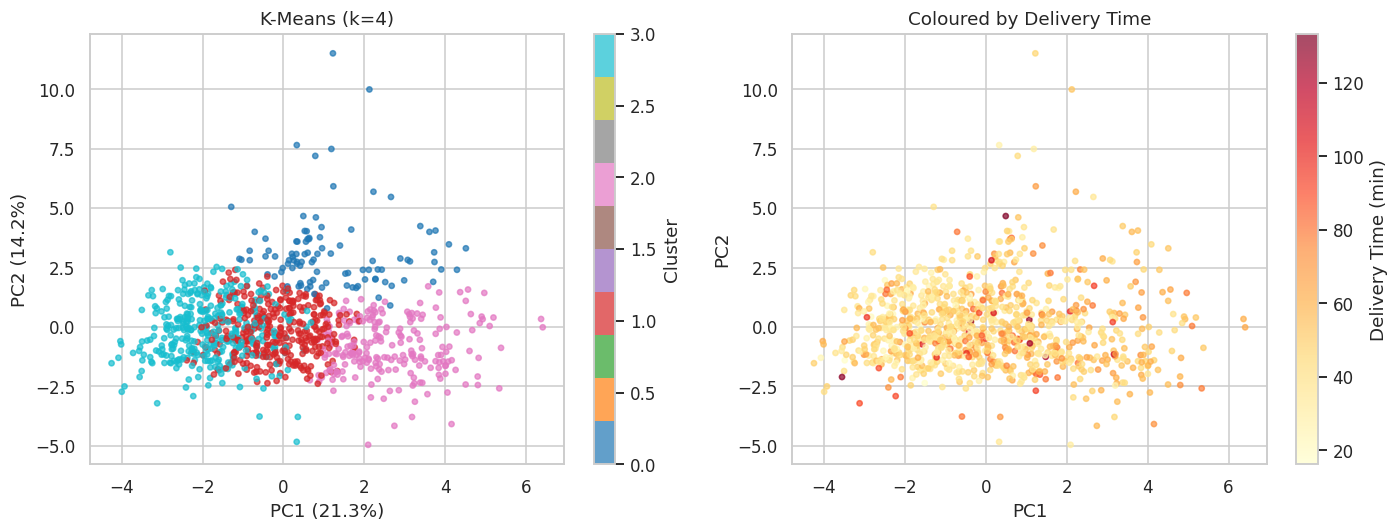

In [18]:
Xt       = cluster_pipe.named_steps["prep"].transform(X_clust)
Xt_dense = Xt.toarray() if hasattr(Xt, "toarray") else Xt
pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(Xt_dense)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sc1 = axes[0].scatter(X_pca[:,0], X_pca[:,1], c=df["cluster"], cmap="tab10", s=12, alpha=0.7)
plt.colorbar(sc1, ax=axes[0], label="Cluster")
axes[0].set(title=f"K-Means (k={K})", xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
sc2 = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=df["delivery_minutes"], cmap="YlOrRd", s=12, alpha=0.7)
plt.colorbar(sc2, ax=axes[1], label="Delivery Time (min)")
axes[1].set(title="Coloured by Delivery Time", xlabel="PC1", ylabel="PC2")
plt.tight_layout(); plt.show()


,Avg Items,Avg Subtotal,Avg Delivery (min),Busy Ratio,Orders/Partner,Complaint Rate
cluster,,,,,,
0,1.60,3005.00,50.04,1.03,1.31,0.18
1,3.15,2619.34,47.26,0.89,1.09,0.21
2,3.95,3190.00,53.07,1.02,1.67,0.40
3,3.08,2309.25,42.83,0.90,1.03,0.20


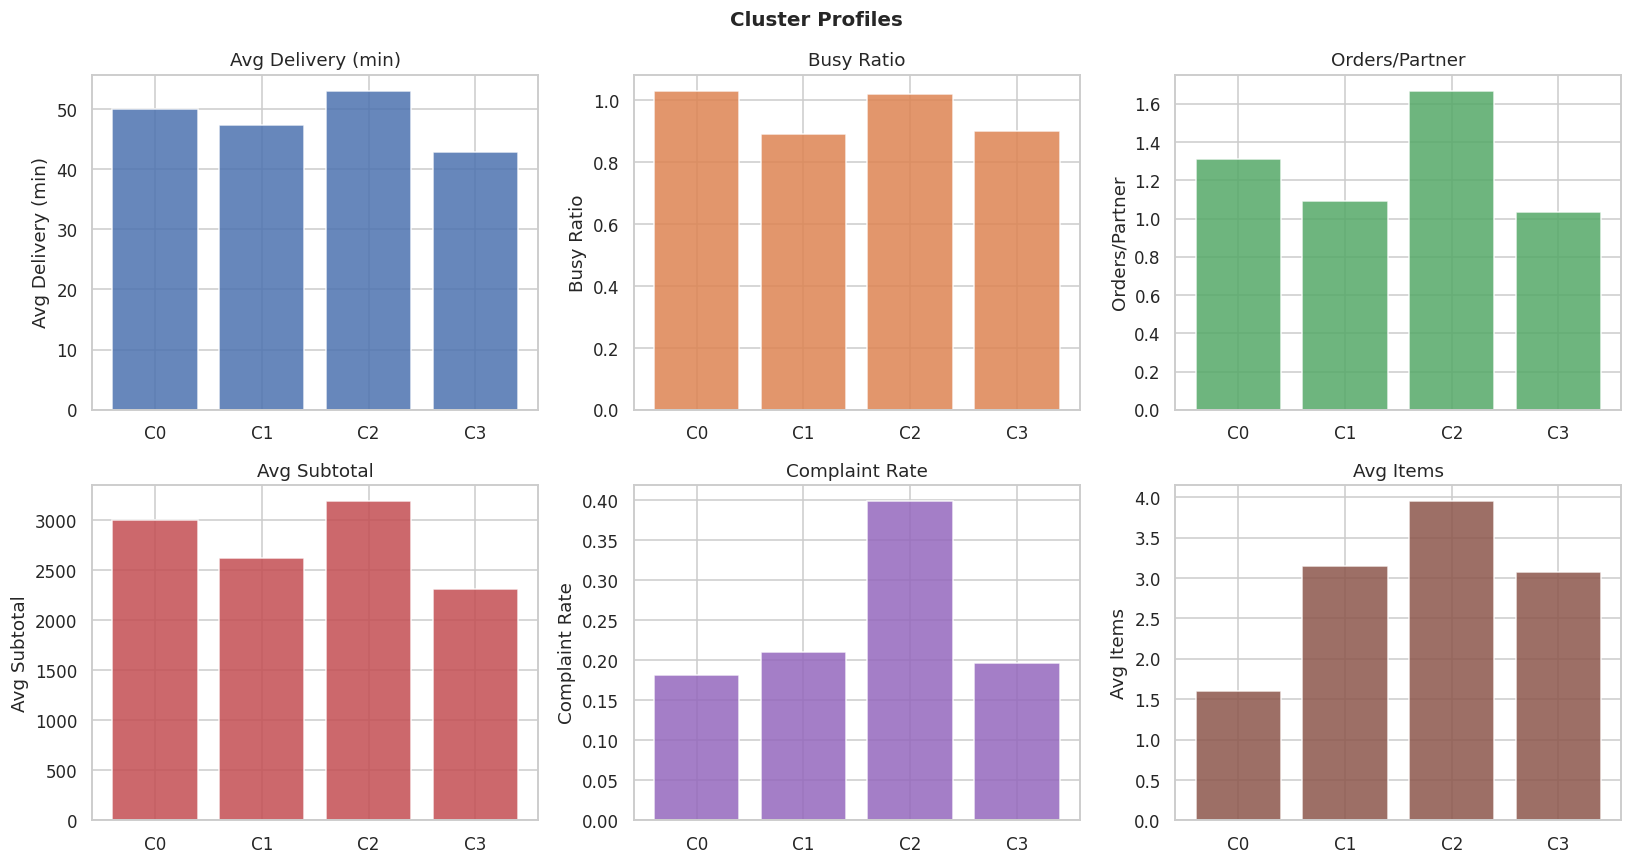

In [19]:
profile = df.groupby("cluster")[["total_items","subtotal","delivery_minutes",
                                  "busy_ratio","orders_per_partner","complaint_flag"]].mean().round(2)
profile.columns = ["Avg Items","Avg Subtotal","Avg Delivery (min)","Busy Ratio","Orders/Partner","Complaint Rate"]
display(profile)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = [("delivery_minutes","Avg Delivery (min)","#4C72B0"),("busy_ratio","Busy Ratio","#DD8452"),
           ("orders_per_partner","Orders/Partner","#55A868"),("subtotal","Avg Subtotal","#C44E52"),
           ("complaint_flag","Complaint Rate","#9467BD"),("total_items","Avg Items","#8C564B")]
for ax,(col,label,color) in zip(axes.flatten(),metrics):
    vals = df.groupby("cluster")[col].mean()
    ax.bar([f"C{i}" for i in vals.index], vals.values, color=color, alpha=0.85, edgecolor="white")
    ax.set(title=label, ylabel=label)
plt.suptitle("Cluster Profiles", fontsize=13, fontweight="bold"); plt.tight_layout(); plt.show()


In [20]:
centers = cluster_pipe.named_steps["km"].cluster_centers_
reps = []
for i in range(K):
    idx   = np.where(df["cluster"]==i)[0]
    dists = pairwise_distances(Xt_dense[idx], centers[i].reshape(1,-1))
    reps.append(idx[np.argmin(dists)])

display(df.iloc[reps][["cluster","market_id","store_primary_category","total_items",
                         "subtotal","created_hour","delivery_minutes",
                         "busy_ratio","complaint_flag"]].reset_index(drop=True))


,cluster,market_id,store_primary_category,total_items,subtotal,created_hour,delivery_minutes,busy_ratio,complaint_flag
0,0,AREA E,pizza,1,2130,2,73.866667,0.943396,0
1,1,AREA C,american,3,2600,3,66.750000,1.078947,0
2,2,AREA D,burger,4,3110,3,53.450000,0.921569,1
3,3,AREA C,pizza,3,2300,21,35.316667,0.913043,0


---
## Task B — Regression

In [ ]:
X_reg = df[ALL_FEATURES].copy(); y_reg = df["delivery_minutes"].copy()
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
print(f"Train: {len(X_train_r)}  |  Test: {len(X_test_r)}")

reg_results = {}
def eval_reg(name, pipe, fitted=False):
    if not fitted: pipe.fit(X_train_r, y_train_r)
    preds = pipe.predict(X_test_r)
    mae   = mean_absolute_error(y_test_r, preds)
    rmse  = np.sqrt(mean_squared_error(y_test_r, preds))
    r2    = r2_score(y_test_r, preds)
    print(f"  {name:<30s}  MAE={mae:.2f}  RMSE={rmse:.2f}  R²={r2:.4f}")
    reg_results[name] = {"MAE":mae, "RMSE":rmse, "R²":r2, "_preds":preds}


Train: 800  |  Test: 200


In [ ]:
# Baseline 1 — Linear Regression
lr_pipe = Pipeline([("prep", make_preprocessor()), ("model", LinearRegression())])
eval_reg("Linear Regression (B1)", lr_pipe)


  Linear Regression (B1)          MAE=13.01  RMSE=17.66  R²=0.1501


In [ ]:
# Baseline 2 — Decision Tree
tree_pipe = Pipeline([("prep", make_preprocessor()), ("model", DecisionTreeRegressor(random_state=42))])
tree_search = RandomizedSearchCV(tree_pipe,
    {"model__max_depth":[3,5,8,12,20,None], "model__min_samples_split":[2,5,10,20],
     "model__min_samples_leaf":[1,2,5,10],  "model__criterion":["squared_error","friedman_mse","absolute_error"]},
    n_iter=30, scoring="neg_mean_absolute_error", cv=5, random_state=42, n_jobs=-1)
tree_search.fit(X_train_r, y_train_r)
print(f"Best params: {tree_search.best_params_}")
eval_reg("Decision Tree (B2)", tree_search.best_estimator_, fitted=True)


Best params: {'model__min_samples_split': 20, 'model__min_samples_leaf': 10, 'model__max_depth': 3, 'model__criterion': 'friedman_mse'}
  Decision Tree (B2)              MAE=12.56  RMSE=17.59  R²=0.1567


In [ ]:
# Main — Random Forest Regressor
rf_reg_pipe = Pipeline([("prep", make_preprocessor()), ("model", RandomForestRegressor(random_state=42))])
rf_reg_search = RandomizedSearchCV(rf_reg_pipe,
    {"model__n_estimators":[100,200,300], "model__max_depth":[5,10,20,None],
     "model__min_samples_split":[2,5,10], "model__min_samples_leaf":[1,2,5],
     "model__max_features":["sqrt","log2",0.5]},
    n_iter=30, scoring="neg_mean_absolute_error", cv=5, random_state=42, n_jobs=-1)
print("Training Random Forest Regressor...")
rf_reg_search.fit(X_train_r, y_train_r)
best_rf_reg = rf_reg_search.best_estimator_
print(f"Best params: {rf_reg_search.best_params_}")
eval_reg("Random Forest ⭐ (Main)", best_rf_reg, fitted=True)


Training Random Forest Regressor...
Best params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 5}
  Random Forest ⭐ (Main)          MAE=12.58  RMSE=17.08  R²=0.2053


In [ ]:
# Results summary
reg_df = pd.DataFrame({k:{m:v for m,v in vals.items() if not m.startswith("_")} for k,vals in reg_results.items()}).T.round(4)
display(reg_df)


,MAE,RMSE,R²
Linear Regression (B1),13.0058,17.6603,0.1501
Decision Tree (B2),12.5576,17.5911,0.1567
Random Forest ⭐ (Main),12.5776,17.0775,0.2053


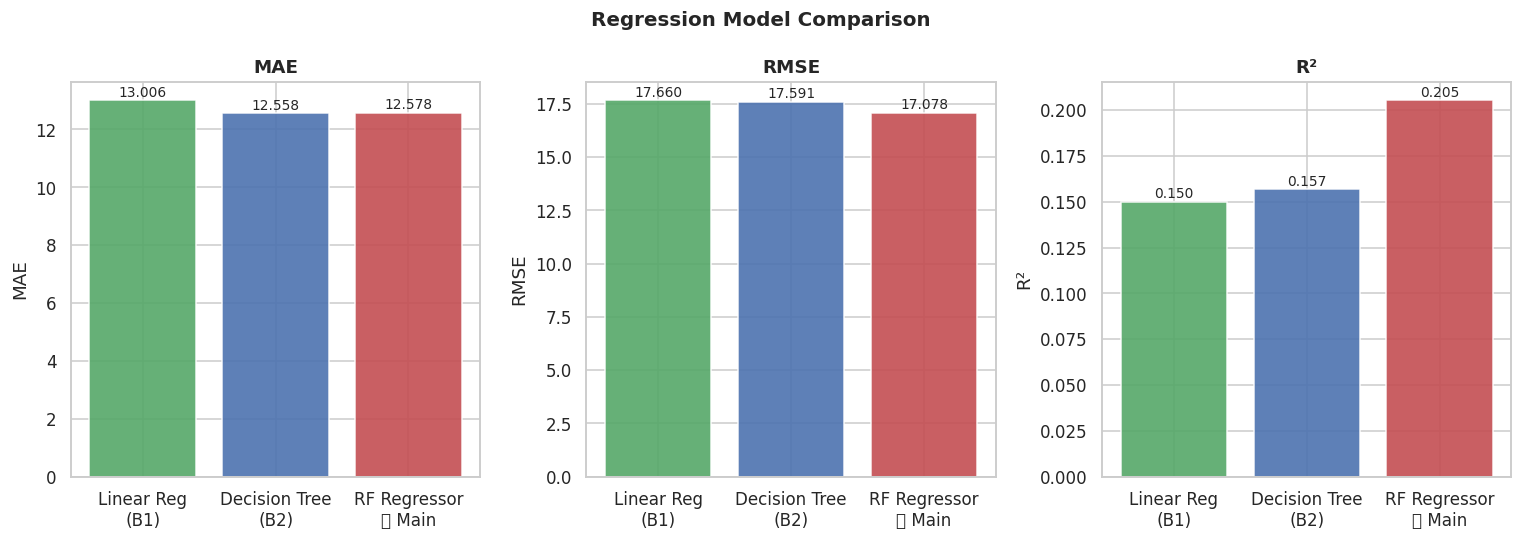

In [ ]:
# Model comparison bar chart
names  = list(reg_results.keys())
labels = ["Linear Reg\n(B1)", "Decision Tree\n(B2)", "RF Regressor\n⭐ Main"]
colors = ["#55A868","#4C72B0","#C44E52"]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metric in zip(axes, ["MAE","RMSE","R²"]):
    vals = [reg_results[m][metric] for m in names]
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", alpha=0.9)
    ax.set_title(metric, fontweight="bold"); ax.set_ylabel(metric)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01, f"{v:.3f}", ha="center", fontsize=9)
plt.suptitle("Regression Model Comparison", fontsize=13, fontweight="bold"); plt.tight_layout(); plt.show()


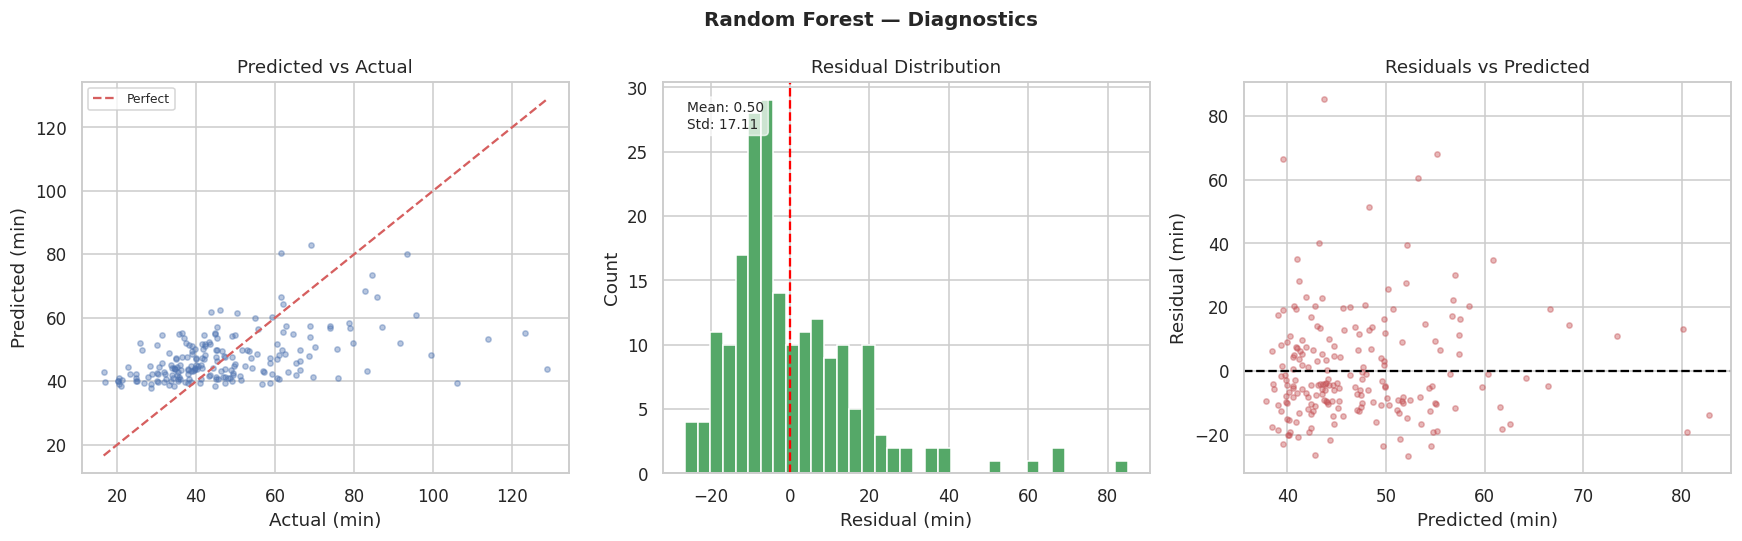

In [ ]:
# Diagnostic plots — Random Forest
rf_preds  = reg_results["Random Forest ⭐ (Main)"]["_preds"]
residuals = y_test_r - rf_preds
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(y_test_r, rf_preds, s=12, alpha=0.4, color="#4C72B0")
lims = [min(y_test_r.min(),rf_preds.min()), max(y_test_r.max(),rf_preds.max())]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect"); axes[0].set(title="Predicted vs Actual", xlabel="Actual (min)", ylabel="Predicted (min)"); axes[0].legend(fontsize=8)

axes[1].hist(residuals, bins=35, color="#55A868", edgecolor="white"); axes[1].axvline(0, color="red", lw=1.5, linestyle="--")
axes[1].set(title="Residual Distribution", xlabel="Residual (min)", ylabel="Count")
axes[1].text(0.05, 0.95, f"Mean: {residuals.mean():.2f}\nStd: {residuals.std():.2f}", transform=axes[1].transAxes, va="top", fontsize=9, bbox=dict(boxstyle="round",facecolor="white",alpha=0.7))

axes[2].scatter(rf_preds, residuals, s=12, alpha=0.4, color="#C44E52"); axes[2].axhline(0, color="black", lw=1.5, linestyle="--")
axes[2].set(title="Residuals vs Predicted", xlabel="Predicted (min)", ylabel="Residual (min)")

plt.suptitle("Random Forest — Diagnostics", fontsize=13, fontweight="bold"); plt.tight_layout(); plt.show()


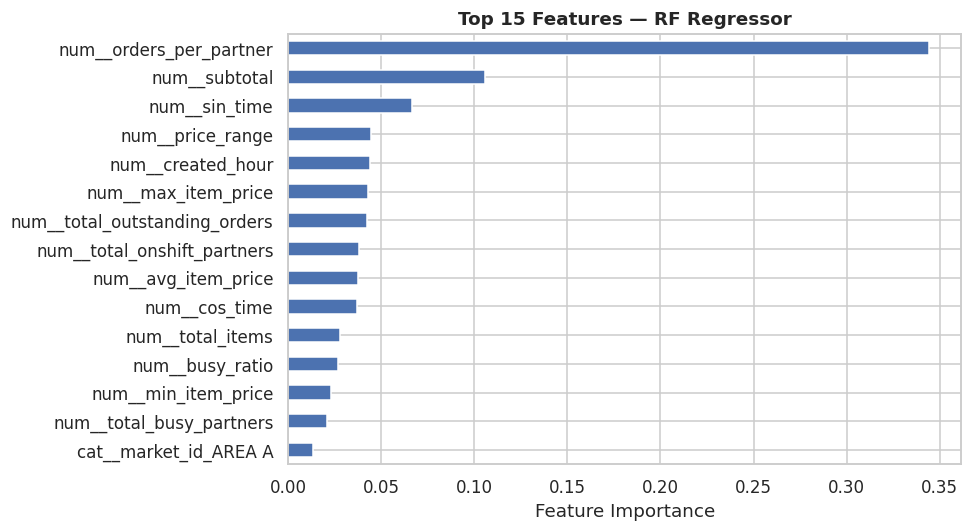

In [ ]:
# Feature importances — Random Forest
rf_model = best_rf_reg.named_steps["model"]
prep_fit = best_rf_reg.named_steps["prep"]
try:    feat_names = prep_fit.get_feature_names_out()
except: feat_names = NUM_COLS + prep_fit.transformers_[1][1].named_steps["enc"].get_feature_names_out(CAT_COLS).tolist()

top15 = pd.Series(rf_model.feature_importances_, index=feat_names).sort_values(ascending=False).head(15)
plt.figure(figsize=(9, 5))
top15.sort_values().plot(kind="barh", color="#4C72B0", edgecolor="white")
plt.xlabel("Feature Importance"); plt.title("Top 15 Features — RF Regressor", fontweight="bold"); plt.tight_layout(); plt.show()


In [ ]:
# 5-fold cross-validation
cv_mae = -cross_val_score(best_rf_reg, X_reg, y_reg, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
print("5-Fold CV — Random Forest Regressor")
for i, v in enumerate(cv_mae, 1): print(f"  Fold {i}: {v:.2f} min")
print(f"  Mean ± Std: {cv_mae.mean():.2f} ± {cv_mae.std():.2f} min")


5-Fold CV — Random Forest Regressor
  Fold 1: 10.64 min
  Fold 2: 11.94 min
  Fold 3: 12.00 min
  Fold 4: 11.05 min
  Fold 5: 11.76 min
  Mean ± Std: 11.48 ± 0.54 min


---
## Task C — Classification

In [21]:
X_clf = df[ALL_FEATURES].copy(); y_clf = df["complaint_flag"].copy()

print("Class distribution:")
for label, count in y_clf.value_counts().items():
    print(f"  {'Complaint' if label==1 else 'No Complaint'} ({label}): {count}  ({count/len(y_clf):.1%})")

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
print(f"Train: {len(X_train_c)}  |  Test: {len(X_test_c)}")

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_results = {}

def eval_clf(name, pipe, threshold=0.5, fitted=False):
    if not fitted: pipe.fit(X_train_c, y_train_c)
    probs = pipe.predict_proba(X_test_c)[:, 1]
    preds = (probs >= threshold).astype(int)
    f1   = f1_score(y_test_c, preds, zero_division=0)
    prec = precision_score(y_test_c, preds, zero_division=0)
    rec  = recall_score(y_test_c, preds)
    roc  = roc_auc_score(y_test_c, probs)
    ap   = average_precision_score(y_test_c, probs)
    print(f"  {name:<42s}  F1={f1:.3f}  P={prec:.3f}  R={rec:.3f}  AUC={roc:.3f}  AP={ap:.3f}")
    clf_results[name] = {"F1":f1,"Precision":prec,"Recall":rec,"ROC-AUC":roc,"Avg Precision":ap,
                         "_probs":probs,"_preds":preds,"_pipe":pipe}


Class distribution:
  No Complaint (0): 756  (75.6%)
  Complaint (1): 244  (24.4%)
Train: 800  |  Test: 200


In [22]:
# Baseline 1 — Naïve Bayes
nb_pipe = Pipeline([("prep", make_preprocessor()), ("model", GaussianNB())])
nb_pipe.fit(X_train_c, y_train_c)
eval_clf("Naïve Bayes (B1)", nb_pipe, fitted=True)


  Naïve Bayes (B1)                            F1=0.395  P=0.249  R=0.959  AUC=0.513  AP=0.250


In [23]:
# Baseline 2 — Random Forest Classifier
rf_clf_pipe = Pipeline([("prep", make_preprocessor()), ("model", RandomForestClassifier(random_state=42))])
rf_clf_search = RandomizedSearchCV(rf_clf_pipe,
    {"model__n_estimators":[200,300,400,500], "model__max_depth":[8,12,20,30,None],
     "model__min_samples_split":[2,4,6,10],   "model__min_samples_leaf":[1,2,3,5],
     "model__max_features":["sqrt","log2",0.3,0.4],
     "model__class_weight":["balanced","balanced_subsample"],
     "model__criterion":["gini","entropy"]},
    n_iter=60, scoring="f1", cv=cv_strat, random_state=42, n_jobs=-1, verbose=0)
print("Training Random Forest Classifier...")
rf_clf_search.fit(X_train_c, y_train_c)
best_rf_clf = rf_clf_search.best_estimator_
print(f"Best params: {rf_clf_search.best_params_}")
eval_clf("Random Forest (B2)", best_rf_clf, fitted=True)


Training Random Forest Classifier...
Best params: {'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 8, 'model__criterion': 'gini', 'model__class_weight': 'balanced'}
  Random Forest (B2)                          F1=0.472  P=0.525  R=0.429  AUC=0.683  AP=0.463


In [24]:
# Main — Logistic Regression (tuned)
logreg_pipe = Pipeline([
    ("prep",  make_preprocessor()),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])
logreg_search = RandomizedSearchCV(logreg_pipe,
    {"model__C":[0.001,0.01,0.1,1,10,100]},
    n_iter=6, scoring="f1", cv=cv_strat, random_state=42, n_jobs=-1)
logreg_search.fit(X_train_c, y_train_c)
best_logreg = logreg_search.best_estimator_
print(f"Best C: {logreg_search.best_params_}  |  CV F1: {logreg_search.best_score_:.4f}")
eval_clf("Logistic Regression ⭐ (Main)", best_logreg, fitted=True)


Best C: {'model__C': 0.1}  |  CV F1: 0.4477
  Logistic Regression ⭐ (Main)                F1=0.475  P=0.397  R=0.592  AUC=0.696  AP=0.484


Optimal threshold: 0.54  (train CV F1 = 0.4541)


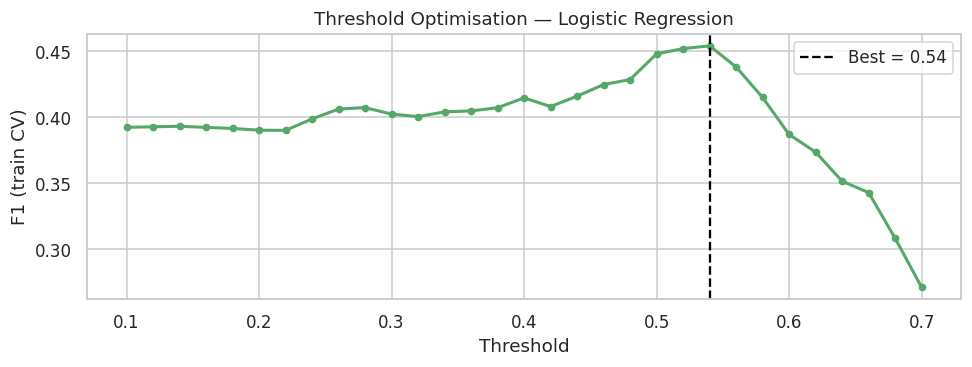

  Logistic Regression ⭐ (t=0.54)              F1=0.491  P=0.456  R=0.531  AUC=0.696  AP=0.484


In [25]:
# Optimal threshold — Logistic Regression
train_probs_lr = cross_val_predict(
    best_logreg, X_train_c, y_train_c, cv=cv_strat, method="predict_proba", n_jobs=-1)[:, 1]
thresholds = np.arange(0.10, 0.71, 0.02)
f1_tr = [f1_score(y_train_c, (train_probs_lr>=t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_tr)]
print(f"Optimal threshold: {best_thresh:.2f}  (train CV F1 = {max(f1_tr):.4f})")

plt.figure(figsize=(9, 3.5))
plt.plot(thresholds, f1_tr, marker="o", markersize=4, color="#55A868", lw=2)
plt.axvline(best_thresh, color="black", linestyle="--", lw=1.5, label=f"Best = {best_thresh:.2f}")
plt.xlabel("Threshold"); plt.ylabel("F1 (train CV)"); plt.title("Threshold Optimisation — Logistic Regression"); plt.legend()
plt.tight_layout(); plt.show()

eval_clf(f"Logistic Regression ⭐ (t={best_thresh:.2f})", best_logreg, threshold=best_thresh, fitted=True)


In [26]:
# Results summary
clf_df = pd.DataFrame({k:{m:v for m,v in vals.items() if not m.startswith("_")} for k,vals in clf_results.items()}).T.round(4)
display(clf_df)
print(f"\n✓ Best F1: {clf_df['F1'].idxmax()}  ({clf_df['F1'].max():.4f})")


,F1,Precision,Recall,ROC-AUC,Avg Precision
Naïve Bayes (B1),0.3950,0.2487,0.9592,0.5126,0.2498
Random Forest (B2),0.4719,0.5250,0.4286,0.6832,0.4635
Logistic Regression ⭐ (Main),0.4754,0.3973,0.5918,0.6963,0.4839
Logistic Regression ⭐ (t=0.54),0.4906,0.4561,0.5306,0.6963,0.4839



✓ Best F1: Logistic Regression ⭐ (t=0.54)  (0.4906)


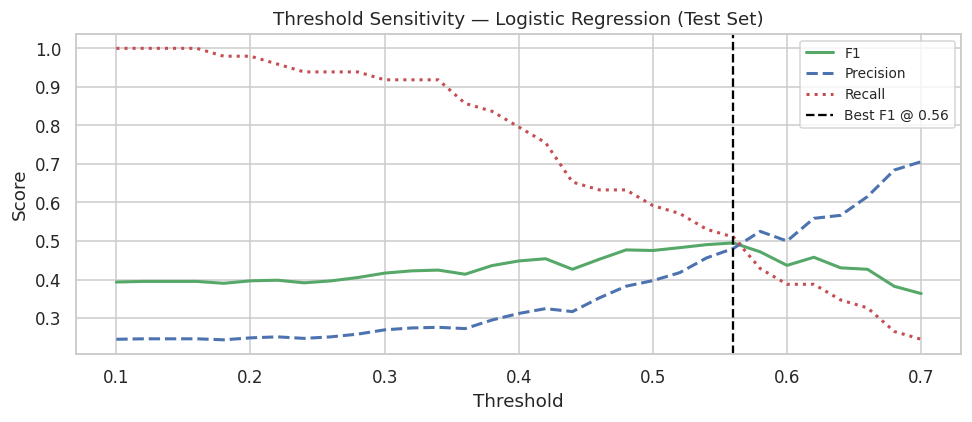

In [27]:
# Threshold sensitivity — Logistic Regression on test set
lr_key   = f"Logistic Regression ⭐ (t={best_thresh:.2f})"
lr_probs = clf_results[lr_key]["_probs"]
thr_test = np.arange(0.10, 0.71, 0.02)
f1_te   = [f1_score(y_test_c, (lr_probs>=t).astype(int), zero_division=0) for t in thr_test]
prec_te = [precision_score(y_test_c, (lr_probs>=t).astype(int), zero_division=0) for t in thr_test]
rec_te  = [recall_score(y_test_c, (lr_probs>=t).astype(int)) for t in thr_test]

plt.figure(figsize=(9, 4))
plt.plot(thr_test, f1_te,   label="F1",        color="#55A868", lw=2)
plt.plot(thr_test, prec_te, label="Precision", color="#4C72B0", lw=2, linestyle="--")
plt.plot(thr_test, rec_te,  label="Recall",    color="#C44E52", lw=2, linestyle=":")
plt.axvline(thr_test[np.argmax(f1_te)], color="black", linestyle="--", lw=1.5, label=f"Best F1 @ {thr_test[np.argmax(f1_te)]:.2f}")
plt.xlabel("Threshold"); plt.ylabel("Score"); plt.title("Threshold Sensitivity — Logistic Regression (Test Set)"); plt.legend(fontsize=9)
plt.tight_layout(); plt.show()


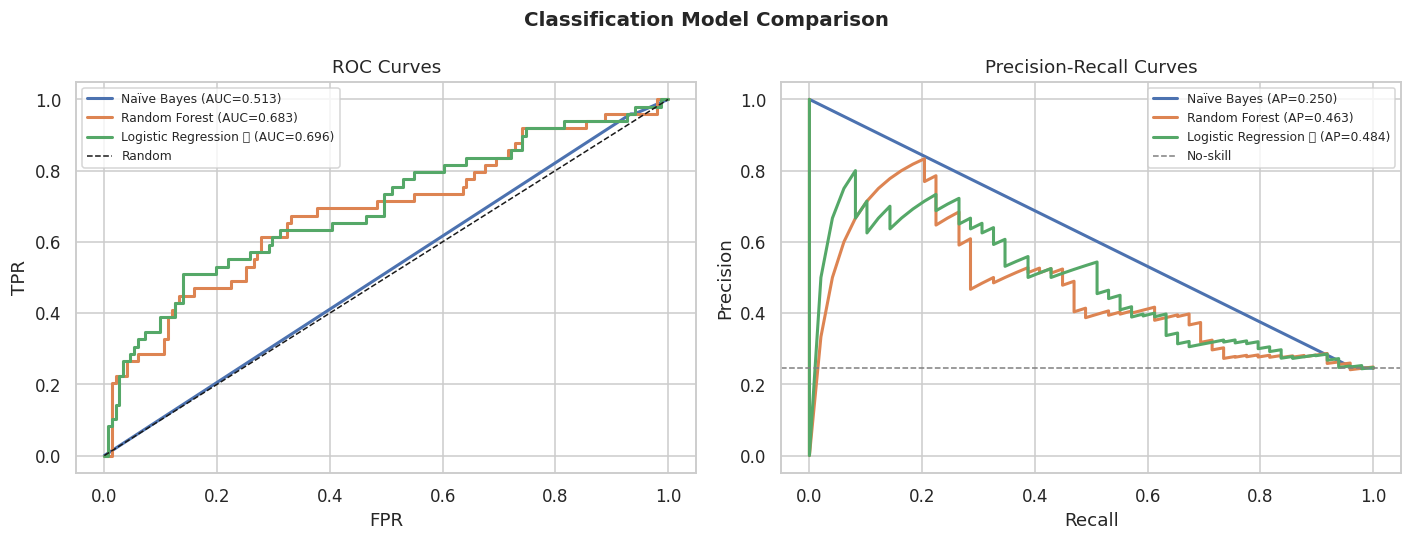

In [28]:
# ROC + Precision-Recall curves
base_keys  = ["Naïve Bayes (B1)", "Random Forest (B2)", "Logistic Regression ⭐ (Main)"]
base_keys  = [k for k in base_keys if k in clf_results]
colors_clf = ["#4C72B0","#DD8452","#55A868"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, color in zip(base_keys, colors_clf):
    probs = clf_results[name]["_probs"]; short = name.split("(")[0].strip()
    fpr, tpr, _ = roc_curve(y_test_c, probs)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{short} (AUC={clf_results[name]['ROC-AUC']:.3f})")
    pc, rc, _ = precision_recall_curve(y_test_c, probs)
    axes[1].plot(rc, pc, color=color, lw=2, label=f"{short} (AP={clf_results[name]['Avg Precision']:.3f})")

axes[0].plot([0,1],[0,1],"k--",lw=1,label="Random"); axes[0].set(title="ROC Curves",xlabel="FPR",ylabel="TPR"); axes[0].legend(fontsize=8)
axes[1].axhline(y_test_c.mean(),color="gray",linestyle="--",lw=1,label="No-skill"); axes[1].set(title="Precision-Recall Curves",xlabel="Recall",ylabel="Precision"); axes[1].legend(fontsize=8)
plt.suptitle("Classification Model Comparison", fontsize=13, fontweight="bold"); plt.tight_layout(); plt.show()


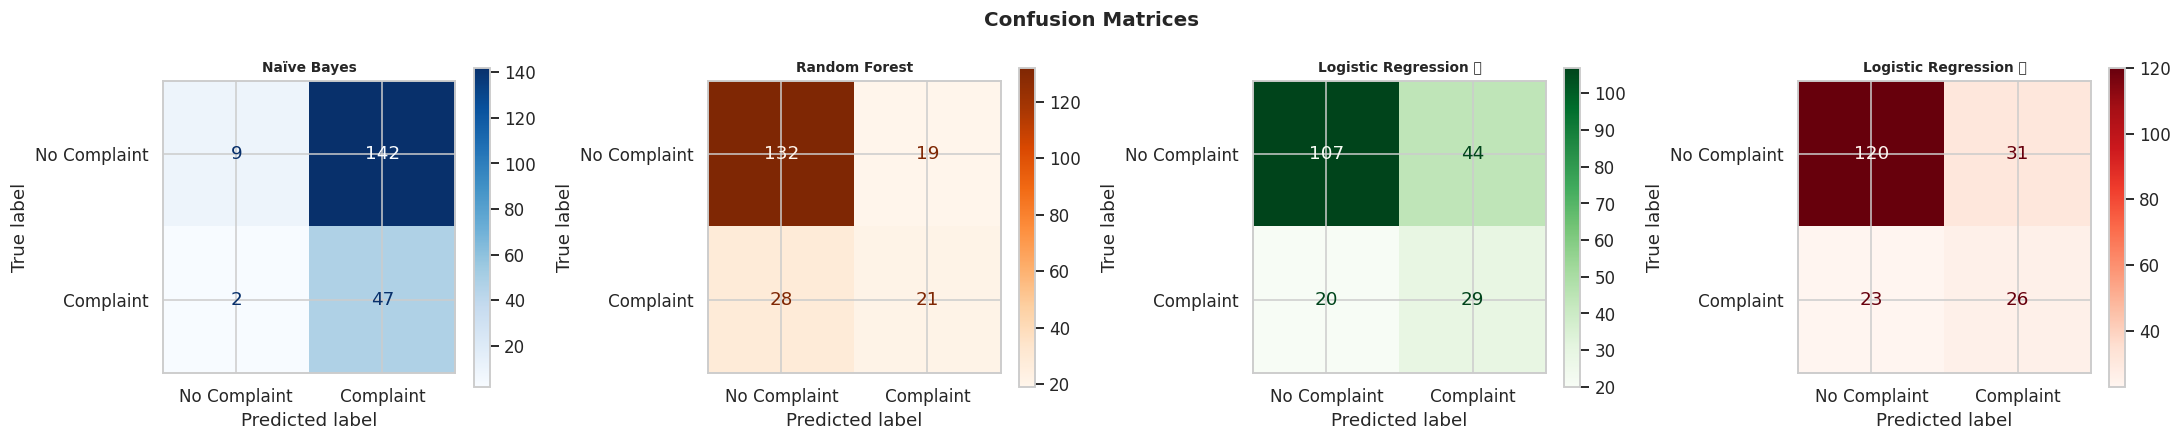

In [29]:
# Confusion matrices
cm_keys = base_keys + [lr_key]
cm_keys = [k for k in cm_keys if k in clf_results]
fig, axes = plt.subplots(1, len(cm_keys), figsize=(5*len(cm_keys), 4))
if len(cm_keys)==1: axes=[axes]
for ax, key, cmap in zip(axes, cm_keys, ["Blues","Oranges","Greens","Reds"]):
    ConfusionMatrixDisplay.from_predictions(y_test_c, clf_results[key]["_preds"],
        display_labels=["No Complaint","Complaint"], cmap=cmap, ax=ax)
    ax.set_title(key.split("(")[0].strip(), fontweight="bold", fontsize=9)
plt.suptitle("Confusion Matrices", fontsize=13, fontweight="bold"); plt.tight_layout(); plt.show()


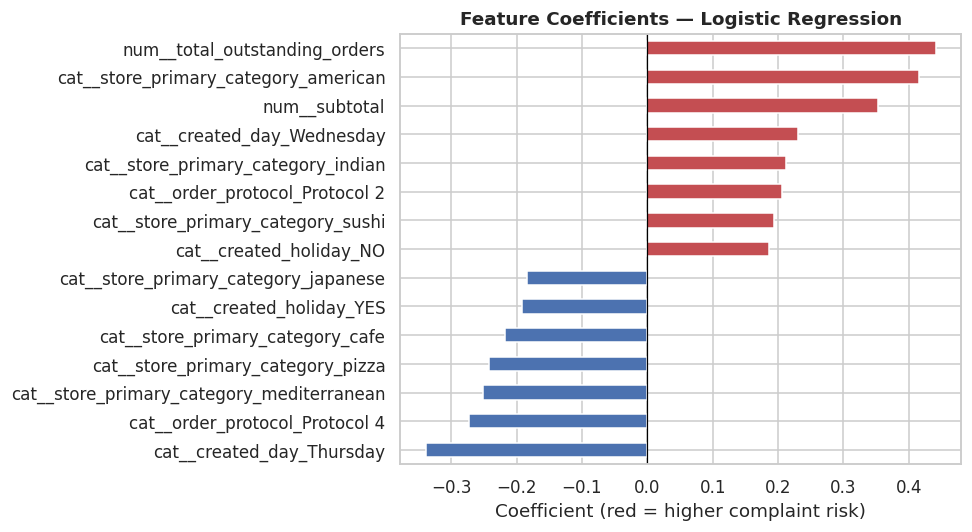

In [30]:
# Logistic Regression coefficients (feature weights)
prep_lr  = best_logreg.named_steps["prep"]
model_lr = best_logreg.named_steps["model"]
try:    feat_names_lr = prep_lr.get_feature_names_out()
except: feat_names_lr = NUM_COLS + prep_lr.transformers_[1][1].named_steps["enc"].get_feature_names_out(CAT_COLS).tolist()

coef     = pd.Series(model_lr.coef_[0], index=feat_names_lr)
top15_lr = coef[coef.abs().sort_values(ascending=False).head(15).index]
colors_c = ["#C44E52" if v > 0 else "#4C72B0" for v in top15_lr.sort_values().values]

plt.figure(figsize=(9, 5))
top15_lr.sort_values().plot(kind="barh", color=colors_c, edgecolor="white")
plt.axvline(0, color="black", lw=0.8)
plt.xlabel("Coefficient (red = higher complaint risk)"); plt.title("Feature Coefficients — Logistic Regression", fontweight="bold")
plt.tight_layout(); plt.show()


In [31]:
# 5-fold cross-validation
cv_f1 = cross_val_score(best_logreg, X_clf, y_clf, cv=cv_strat, scoring="f1", n_jobs=-1)
print("5-Fold CV — Logistic Regression")
for i, v in enumerate(cv_f1, 1): print(f"  Fold {i}: F1 = {v:.4f}")
print(f"  Mean ± Std: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")


5-Fold CV — Logistic Regression
  Fold 1: F1 = 0.4262
  Fold 2: F1 = 0.4552
  Fold 3: F1 = 0.4870
  Fold 4: F1 = 0.4035
  Fold 5: F1 = 0.3964
  Mean ± Std: 0.4337 ± 0.0336


---
## Summary

| Task | Main Model | Baselines |
|------|-----------|----------|
| A — Clustering | K-Means (k=4) | — |
| B — Regression | Random Forest ⭐ | Linear Regression, Decision Tree |
| C — Classification | Logistic Regression ⭐ | Naïve Bayes, Random Forest |